In [4]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["PYTHONHASHSEED"] = "0"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"   # IMPORTANT for CUDA determinism

# Add the project root to sys.path
module_path = os.path.abspath(os.path.join('../../'))
if module_path not in sys.path:
    sys.path.append(module_path)

# PyTorch imports
import torch.nn as nn
import torch.nn.functional as F

from fuzzy_network_pytorch.FuzzyLayer import FuzzyLayer
from fuzzy_network_pytorch.FuzzyLayer_Gauss import FuzzyLayer_Gauss
from fuzzy_network_pytorch.FuzzyNetwork import FuzzyNetwork  # Optional if used later
%load_ext autoreload
%autoreload 2
# Avoid potential OpenMP conflicts
import os
import pandas as pd
import time
import torch
import matplotlib.pyplot as plt
from datetime import datetime
from neural_network_bma_pytorch.bma import ModelWrapper 
from neural_network_bma_pytorch.NeuralNetwork_pytorch import  NeuralNetwork
def set_seed(seed=42):
    # Python RNG
    random.seed(seed)

    # NumPy RNG
    np.random.seed(seed)

    # PyTorch RNGs
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Make cuDNN deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Extra safety for full determinism (PyTorch ≥ 1.8)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True)

    print(f"Random seed set to {seed} (deterministic mode ON).")

# Call it:
set_seed(42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Random seed set to 42 (deterministic mode ON).


In [3]:


import time

import torch
from neural_network_bma_pytorch import levenberg_marquardt_pytorch as tlm
from torch.utils.data import TensorDataset

# Set PyTorch to use high precision for matrix multiplication
torch.set_float32_matmul_precision('high')

# Detect CUDA device for acceleration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# %%
# Generate synthetic dataset for training
input_size = 200000  # Total number of data points
batch_size = 20000  # Number of samples per batch

# Create input tensor
x_train = torch.linspace(-1, 1, input_size, dtype=torch.float32).unsqueeze(1)

# Compute sinc using torch
y_train = torch.sinc(10 * x_train)  # PyTorch has torch.sinc

# Move to device
x_train = x_train.to(device)
y_train = y_train.to(device)

# Create dataset and dataloader
train_dataset = TensorDataset(x_train, y_train)
train_loader = tlm.FastDataLoader(
    train_dataset,
    batch_size=batch_size,
    repeat=1,
    shuffle=True,
    device=device,
)


Using device: cuda


Random seed set to 42 (deterministic mode ON).

--- Running Experiment: Mode=BMA, Act=tanh, Opt=lm ---


Training:   0%|          | 0/100 [00:00<?, ?epoch/s]c:\Users\LUH1BP\Projects\Fuzzy\fuzzy-bma\neural_network_bma_pytorch\bea\population_module\PopulationAbstract.py:102: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(self.inp.observations, dtype=torch.float32, device=device)
c:\Users\LUH1BP\Projects\Fuzzy\fuzzy-bma\neural_network_bma_pytorch\bea\population_module\PopulationAbstract.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y = torch.tensor(self.inp.desired_outputs, dtype=torch.float32, device=device)
c:\Users\LUH1BP\Projects\Fuzzy\fuzzy-bma\neural_network_bma_pytorch\bea\population_module\PopulationAbstract.py:59: UserWarning: To copy construct from a tensor, i


--- Running Experiment: Mode=BMA, Act=tanh, Opt=adam ---


Training:   0%|          | 0/100 [00:00<?, ?epoch/s]c:\Users\LUH1BP\Projects\Fuzzy\fuzzy-bma\neural_network_bma_pytorch\bea\population_module\PopulationAbstract.py:102: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(self.inp.observations, dtype=torch.float32, device=device)
c:\Users\LUH1BP\Projects\Fuzzy\fuzzy-bma\neural_network_bma_pytorch\bea\population_module\PopulationAbstract.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y = torch.tensor(self.inp.desired_outputs, dtype=torch.float32, device=device)
c:\Users\LUH1BP\Projects\Fuzzy\fuzzy-bma\neural_network_bma_pytorch\bea\population_module\PopulationAbstract.py:59: UserWarning: To copy construct from a tensor, i


--- Running Experiment: Mode=BMA, Act=tanh, Opt=lm_trust_region ---


...

Epoch 100/100: 100%|██████████| 100/100 [00:31<00:00,  3.17epoch/s, loss=0.003858]



--- Running Experiment: Mode=GradOnly, Act=relu, Opt=adam ---


Epoch 100/100: 100%|██████████| 100/100 [00:23<00:00,  4.18epoch/s, loss=0.004778]



--- Running Experiment: Mode=GradOnly, Act=relu, Opt=lm_trust_region ---


Epoch 100/100: 100%|██████████| 100/100 [00:31<00:00,  3.18epoch/s, loss=0.001803]


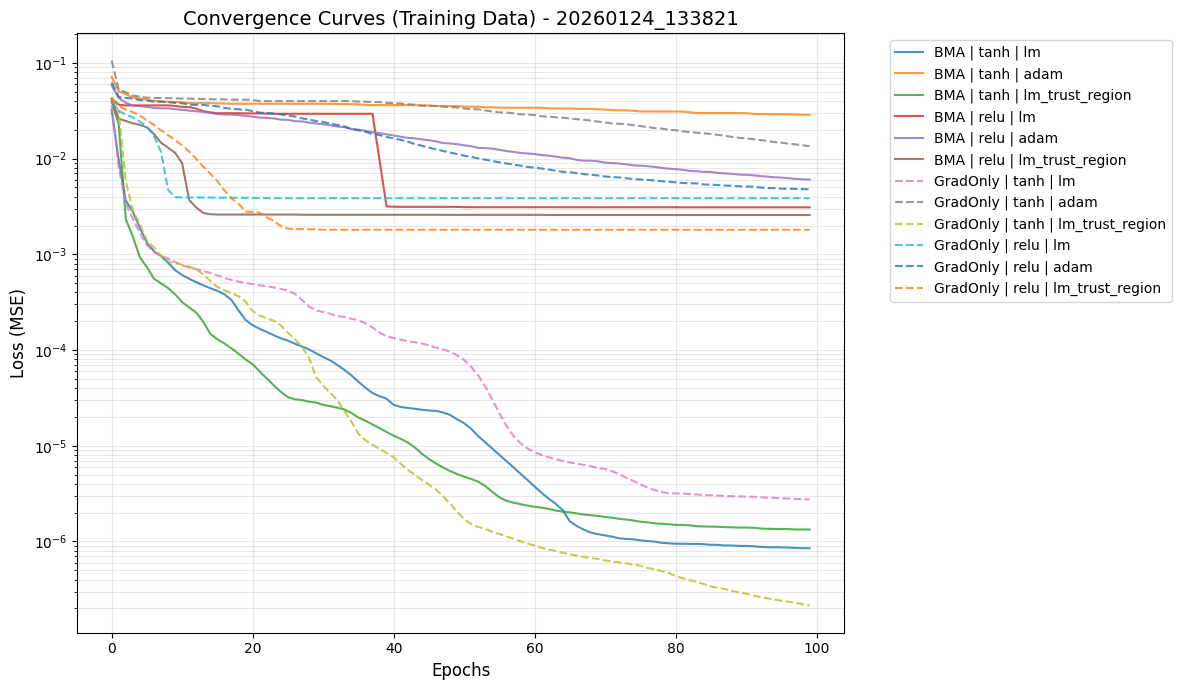


All models saved in: saved_models_bma_20260124_133821
Summary saved as: experiment_summary_20260124_133821.csv


In [ ]:
import os
import pandas as pd
import time
import torch
import matplotlib.pyplot as plt
from datetime import datetime

set_seed(42)
# --- 1. SETUP DIRECTORIES WITH TIMESTAMP ---
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = f"saved_models_bma_{timestamp}"
history_dir = f"learning_histories_bma_{timestamp}"
os.makedirs(save_dir, exist_ok=True)
os.makedirs(history_dir, exist_ok=True)

# Experimental Configurations
activations = ['tanh', 'relu']
optimizers = ['lm', 'adam', 'lm_trust_region']
bea_options = [True, False] 
results_bma = []

# --- 2. EXPERIMENTAL LOOP ---
for bea_status in bea_options:
    for act in activations:
        for opt_name in optimizers:
            mode_label = "BMA" if bea_status else "GradOnly"
            print(f"\n--- Running Experiment: Mode={mode_label}, Act={act}, Opt={opt_name} ---")
            
            # 1. Initialize Model
            nn_model = NeuralNetwork(layers=[[1, 20, act], [20, 1, 'linear']]).to(device)
            total_params = sum(p.numel() for p in nn_model.parameters() if p.requires_grad)
            
            # 2. Wrap and Compile
            model_wrapper = ModelWrapper(nn_model)
            model_wrapper.compile(
                grad_based_optimizer_name=opt_name,
                learning_rate=0.01 if opt_name == 'adam' else 1.0,
                loss_fn=tlm.MSELoss(),
                bea_enabled=bea_status,
                n_ind=10 if bea_status else 1,
                n_gen=1,
                n_clone=5 if bea_status else 0,
                n_inf=2 if bea_status else 0,
                grad_based_method_iter=1
            )
            
            # 3. Train
            start_t = time.perf_counter()
            # Training on train_loader
            history = model_wrapper.fit(train_loader, epochs=100, verbose=True)
            end_t = time.perf_counter()
            
            # 4. Save History (CSV)
            history_df = pd.DataFrame(history)
            history_filename = f"history_{mode_label}_{act}_{opt_name}.csv"
            history_path = os.path.join(history_dir, history_filename)
            history_df.to_csv(history_path, index_label='epoch')
            
            # 5. Save Model Weights
            model_filename = f"model_{mode_label}_{act}_{opt_name}.pth"
            model_path = os.path.join(save_dir, model_filename)
            torch.save(nn_model.state_dict(), model_path)
            
            # 6. Evaluation (Using train_loader as test_loader is unavailable)
            nn_model.eval()
            train_final_mse = 0.0
            with torch.no_grad():
                for bx, by in train_loader:
                    pred = nn_model(bx)
                    train_final_mse += torch.nn.functional.mse_loss(pred, by).item()
            train_final_mse /= len(train_loader)
            
            # 7. Log Results
            results_bma.append({
                'BEA_Enabled': bea_status,
                'Activation': act,
                'Optimizer': opt_name,
                'Algorithm': mode_label,
                'Final_Train_MSE': train_final_mse,
                'Train_Time_Sec': end_t - start_t,
                'Params': total_params,
                'History_Path': history_path
            })

# Save Final Summary
summary_filename = f"experiment_summary_{timestamp}.csv"
df_results = pd.DataFrame(results_bma)
df_results.to_csv(summary_filename, index=False)

# --- 3. PLOTTING LEARNING CURVES ---
plt.figure(figsize=(12, 7))

for result in results_bma:
    data = pd.read_csv(result['History_Path'])
    label = f"{result['Algorithm']} | {result['Activation']} | {result['Optimizer']}"
    linestyle = '-' if result['BEA_Enabled'] else '--'
    
    plt.plot(data['epoch'], data['loss'], label=label, linestyle=linestyle, alpha=0.8)

plt.title(f"Convergence Curves (Training Data) - {timestamp}", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss (MSE)", fontsize=12)
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig(f"training_curves_{timestamp}.png")
plt.show()

print(f"\nAll models saved in: {save_dir}")
print(f"Summary saved as: {summary_filename}")

Random seed set to 42 (deterministic mode ON).

--- Running Fuzzy Experiment: Mode=BMA, MF=trap, Opt=lm ---
Random seed set to 42 (deterministic mode ON).
cpu


Training:   0%|          | 0/100 [00:00<?, ?epoch/s]c:\Users\LUH1BP\Projects\Fuzzy\fuzzy-bma\neural_network_bma_pytorch\bea\population_module\PopulationAbstract.py:102: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(self.inp.observations, dtype=torch.float32, device=device)
c:\Users\LUH1BP\Projects\Fuzzy\fuzzy-bma\neural_network_bma_pytorch\bea\population_module\PopulationAbstract.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y = torch.tensor(self.inp.desired_outputs, dtype=torch.float32, device=device)
c:\Users\LUH1BP\Projects\Fuzzy\fuzzy-bma\neural_network_bma_pytorch\bea\population_module\PopulationAbstract.py:59: UserWarning: To copy construct from a tensor, i


--- Running Fuzzy Experiment: Mode=BMA, MF=trap, Opt=adam ---
Random seed set to 42 (deterministic mode ON).
cpu


Training:   0%|          | 0/100 [00:00<?, ?epoch/s]c:\Users\LUH1BP\Projects\Fuzzy\fuzzy-bma\neural_network_bma_pytorch\bea\population_module\PopulationAbstract.py:102: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(self.inp.observations, dtype=torch.float32, device=device)
c:\Users\LUH1BP\Projects\Fuzzy\fuzzy-bma\neural_network_bma_pytorch\bea\population_module\PopulationAbstract.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y = torch.tensor(self.inp.desired_outputs, dtype=torch.float32, device=device)
c:\Users\LUH1BP\Projects\Fuzzy\fuzzy-bma\neural_network_bma_pytorch\bea\population_module\PopulationAbstract.py:59: UserWarning: To copy construct from a tensor, i


--- Running Fuzzy Experiment: Mode=BMA, MF=trap, Opt=lm_trust_region ---
Random seed set to 42 (deterministic mode ON).
cpu


...

Epoch 100/100: 100%|██████████| 100/100 [00:32<00:00,  3.10epoch/s, loss=0.005748]



--- Running Fuzzy Experiment: Mode=GradOnly, MF=gauss, Opt=adam ---
Random seed set to 42 (deterministic mode ON).
cpu


Epoch 100/100: 100%|██████████| 100/100 [00:24<00:00,  4.16epoch/s, loss=0.000008]



--- Running Fuzzy Experiment: Mode=GradOnly, MF=gauss, Opt=lm_trust_region ---
Random seed set to 42 (deterministic mode ON).
cpu


Epoch 100/100: 100%|██████████| 100/100 [00:30<00:00,  3.26epoch/s, loss=0.000001]


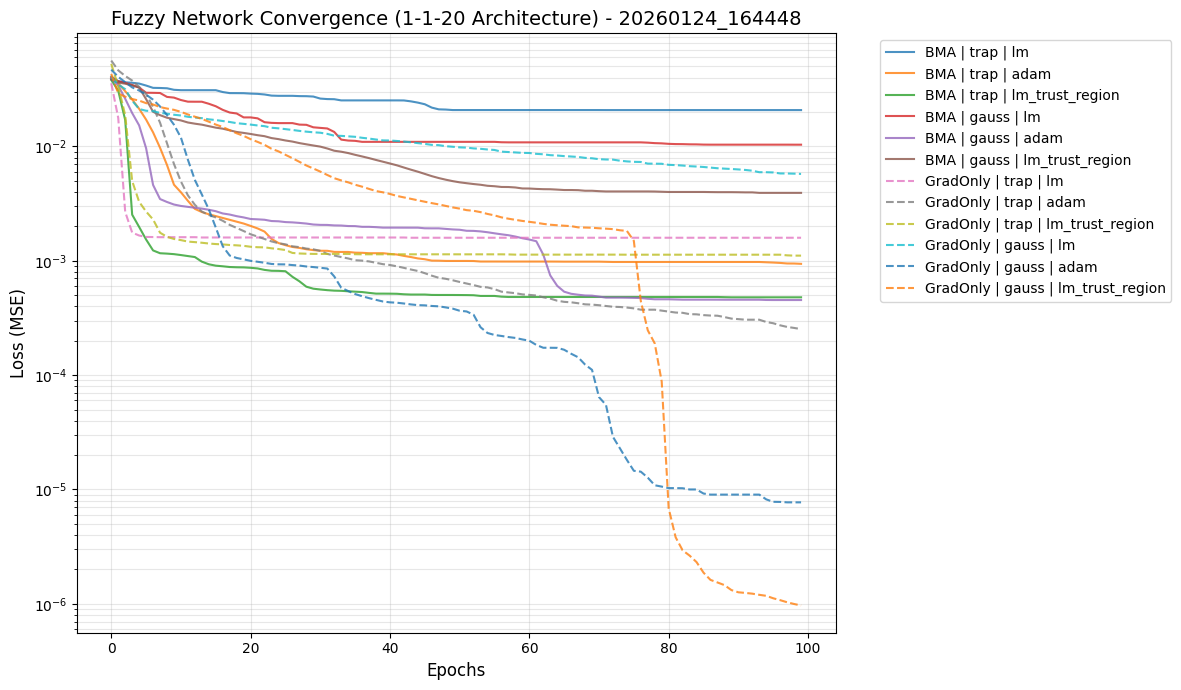

In [13]:
import os
import pandas as pd
import time
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
from datetime import datetime


set_seed(42)

# --- 1. SETUP DIRECTORIES WITH TIMESTAMP ---
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = f"saved_fuzzy_models_{timestamp}"
history_dir = f"learning_histories_fuzzy_{timestamp}"
os.makedirs(save_dir, exist_ok=True)
os.makedirs(history_dir, exist_ok=True)

# Experimental Configurations
ante_memb_types = ['trap', 'gauss'] 
optimizers = ['lm', 'adam', 'lm_trust_region']
bea_options = [True, False] 
results_fuzzy = []

# --- 2. EXPERIMENTAL LOOP ---
for bea_status in bea_options:
    for memb_type in ante_memb_types:
        for opt_name in optimizers:
            mode_label = "BMA" if bea_status else "GradOnly"
            print(f"\n--- Running Fuzzy Experiment: Mode={mode_label}, MF={memb_type}, Opt={opt_name} ---")
            set_seed(42)
            # 1. Initialize Fuzzy Model (1 input, 1 output, 20 rules)
            fuzzy_model = FuzzyNetwork(f_layers=[[1, 1, 20]], 
                                       ante_memb=memb_type, 
                                       cons_memb=memb_type).to(device)
            
            # Use your specific parameter counting method
            # If this returns a flattened tensor, numel() or len() gives the total count
            num_params = len(fuzzy_model.get_trainable_params())
            
            # 2. Wrap and Compile
            model_wrapper = ModelWrapper(fuzzy_model)
            model_wrapper.compile(
                grad_based_optimizer_name=opt_name,
                learning_rate=0.01 if opt_name == 'adam' else 1.0,
                loss_fn=tlm.MSELoss(),
                bea_enabled=bea_status,
                n_ind=10 if bea_status else 1,
                n_gen=1,
                n_clone=5 if bea_status else 0,
                n_inf=2 if bea_status else 0,
                grad_based_method_iter=1
            )
            
            # 3. Train
            start_t = time.perf_counter()
            history = model_wrapper.fit(train_loader, epochs=100, verbose=True)
            end_t = time.perf_counter()
            
            # 4. Save History (CSV)
            history_df = pd.DataFrame(history)
            history_filename = f"history_fuzzy_{mode_label}_{memb_type}_{opt_name}.csv"
            history_path = os.path.join(history_dir, history_filename)
            history_df.to_csv(history_path, index_label='epoch')
            
            # 5. Save Model Weights
            model_filename = f"model_fuzzy_{mode_label}_{memb_type}_{opt_name}.pth"
            model_path = os.path.join(save_dir, model_filename)
            torch.save(fuzzy_model.state_dict(), model_path)
            
            # 6. Evaluation (Training Data)
            fuzzy_model.eval()
            train_final_mse = 0.0
            with torch.no_grad():
                for bx, by in train_loader:
                    pred = fuzzy_model(bx)
                    train_final_mse += torch.nn.functional.mse_loss(pred, by).item()
            train_final_mse /= len(train_loader)
            
            # 7. Log Results
            results_fuzzy.append({
                'BEA_Enabled': bea_status,
                'MF_Type': memb_type,
                'Optimizer': opt_name,
                'Algorithm': mode_label,
                'Final_Train_MSE': train_final_mse,
                'Train_Time_Sec': end_t - start_t,
                'Total_Params': num_params,
                'History_Path': history_path
            })

# Save Final Summary
summary_filename = f"fuzzy_summary_{timestamp}.csv"
df_results = pd.DataFrame(results_fuzzy)
df_results.to_csv(summary_filename, index=False)

# --- 3. PLOTTING LEARNING CURVES ---
plt.figure(figsize=(12, 7))

for result in results_fuzzy:
    data = pd.read_csv(result['History_Path'])
    label = f"{result['Algorithm']} | {result['MF_Type']} | {result['Optimizer']}"
    linestyle = '-' if result['BEA_Enabled'] else '--'
    
    plt.plot(data['epoch'], data['loss'], label=label, linestyle=linestyle, alpha=0.8)

plt.title(f"Fuzzy Network Convergence (1-1-20 Architecture) - {timestamp}", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss (MSE)", fontsize=12)
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig(f"fuzzy_training_curves_{timestamp}.png")
plt.show()

C:\Users\LUH1BP\AppData\Local\Temp\3\ipykernel_41560\2074405179.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nn_eval.load_state_dict(torch.load(path))


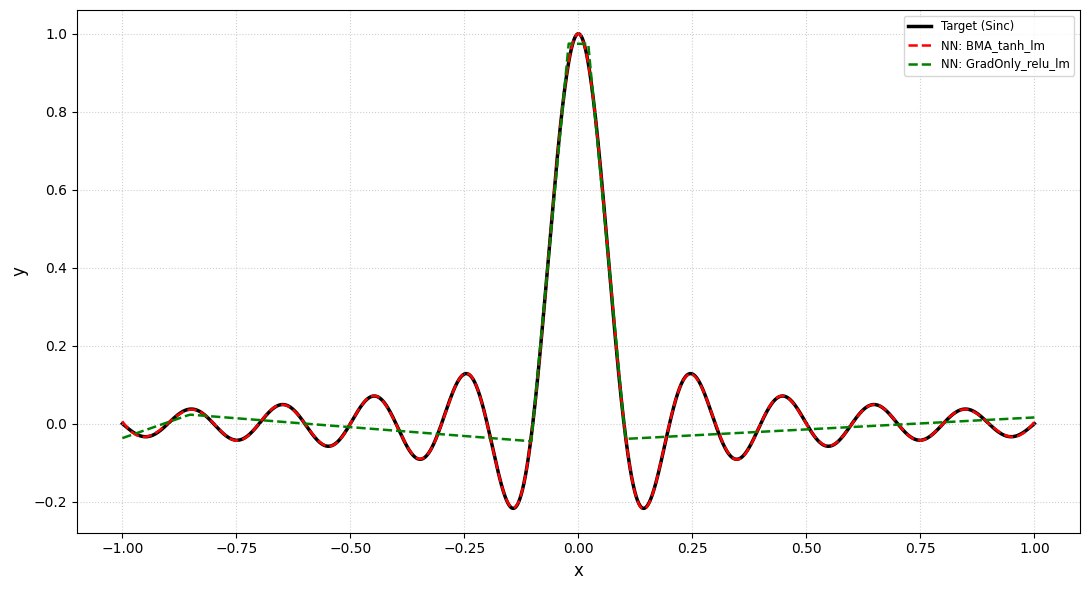

In [34]:
import torch
import matplotlib.pyplot as plt
import os

# --- 1. SETUP ---
# Targeted directory from your specific run
current_run_timestamp = "20260124_133821"
save_dir = f"saved_models_bma_{current_run_timestamp}"

# Build dictionary: "Algorithm_Activation_Optimizer" -> "path/to/model.pth"
nn_model_dict = {
    f"{r['Algorithm']}_{r['Activation']}_{r['Optimizer']}": os.path.join(save_dir, f"model_{r['Algorithm']}_{r['Activation']}_{r['Optimizer']}.pth")
    for r in results_bma
}

# --- 2. SELECT MODELS AND COLORS ---
selected_nn_keys = ["BMA_tanh_lm", "GradOnly_relu_lm"]
colors = ['red', 'green'] # Custom colors for the predictions

# --- 3. PREPARE DATA ---
x_plot, indices = torch.sort(x_train, dim=0)
y_true = y_train[indices].cpu().numpy().flatten()
x_plot_np = x_plot.cpu().numpy().flatten()

plt.figure(figsize=(11, 6))

# Target: Bold Solid Black Line
plt.plot(x_plot_np, y_true, color='black', label='Target (Sinc)', linewidth=2.5, zorder=1)

# --- 4. LOOP AND PLOT SELECTED PREDICTIONS ---
for i, key in enumerate(selected_nn_keys):
    if key in nn_model_dict:
        path = nn_model_dict[key]
        act_func = key.split('_')[1]
        
        # Initialize and Load
        nn_eval = NeuralNetwork(layers=[[1, 20, act_func], [20, 1, 'linear']]).to(device)
        nn_eval.load_state_dict(torch.load(path))
        nn_eval.eval()
        
        with torch.no_grad():
            y_pred = nn_eval(x_plot).cpu().numpy().flatten()
        
        # Predictions: Dashed Lines with specific colors
        plt.plot(x_plot_np, y_pred, label=f"NN: {key}", color=colors[i], linestyle='--', linewidth=1.8)
    else:
        print(f"Key '{key}' not found in nn_model_dict.")

# --- 5. FORMATTING (Scientific Style) ---
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend(loc='upper right', fontsize='small', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Save for documentation
plt.savefig(f"nn_red_green_comparison_{current_run_timestamp}.png", dpi=300)
plt.show()

cpu
cpu


C:\Users\LUH1BP\AppData\Local\Temp\3\ipykernel_41560\2780930561.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_eval.load_state_dict(torch.load(path))


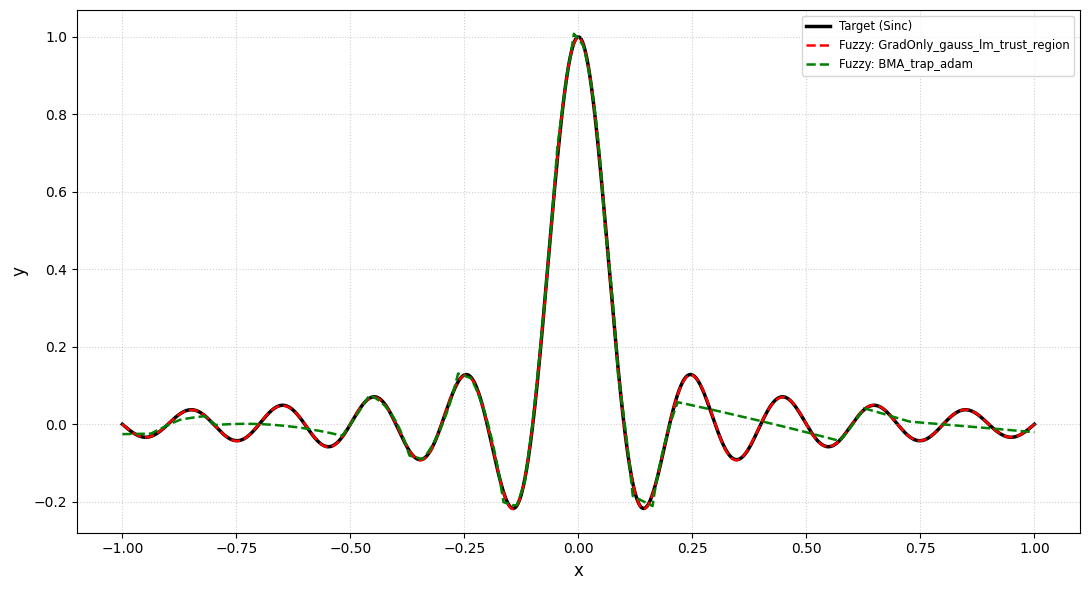

In [35]:
import torch
import matplotlib.pyplot as plt
import os

# --- 1. SETUP & DIRECTORY ---
current_run_timestamp = "20260124_164448"
save_dir = f"saved_fuzzy_models_{current_run_timestamp}"

# Build the model dictionary from previous results
model_dict = {
    f"{r['Algorithm']}_{r['MF_Type']}_{r['Optimizer']}": os.path.join(save_dir, f"model_fuzzy_{r['Algorithm']}_{r['MF_Type']}_{r['Optimizer']}.pth")
    for r in results_fuzzy
}

# --- 2. SELECT MODELS & ASSIGN COLORS ---
selected_keys = ["GradOnly_gauss_lm_trust_region", "BMA_trap_adam"]
colors = ['red', 'green'] 

# --- 3. PREPARE DATA ---
x_plot = x_train.sort(dim=0).values
y_true = y_train[x_train.sort(dim=0).indices].cpu().numpy().flatten()
x_plot_np = x_plot.cpu().numpy().flatten()

plt.figure(figsize=(11, 6))

# Target: Bold Solid Black Line
plt.plot(x_plot_np, y_true, color='black', label='Target (Sinc)', linewidth=2.5, zorder=1)

# --- 4. LOOP AND PLOT SELECTED PREDICTIONS ---
for i, key in enumerate(selected_keys):
    if key in model_dict:
        path = model_dict[key]
        mf_type = key.split('_')[1] 
        
        # Re-initialize the specific architecture (20 rules)
        model_eval = FuzzyNetwork(f_layers=[[1, 1, 20]], 
                                  ante_memb=mf_type, 
                                  cons_memb=mf_type).to(device)
        model_eval.load_state_dict(torch.load(path))
        model_eval.eval()
        
        with torch.no_grad():
            y_pred = model_eval(x_plot).cpu().numpy().flatten()
        
        # Prediction: Dashed Lines in Red/Green
        plt.plot(x_plot_np, y_pred, label=f"Fuzzy: {key}", color=colors[i], linestyle='--', linewidth=1.8)
    else:
        print(f"Key '{key}' not found in model_dict.")

# --- 5. FORMATTING ---
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend(loc='upper right', fontsize='small', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Save for documentation
plt.savefig(f"fuzzy_red_green_comparison_{current_run_timestamp}.png", dpi=300)
plt.show()

In [38]:
import pandas as pd
import os

# Define the specific filename provided
filename = 'fuzzy_summary_20260124_164448.csv'

if not os.path.exists(filename):
    print(f"Error: The file '{filename}' was not found in the current directory.")
else:
    # Load the summary data
    df = pd.read_csv(filename)

    # 1. Print General Training Overview
    print("=" * 105)
    print(f"{'Algorithm':<12} | {'MF Type':<8} | {'Optimizer':<18} | {'MSE (Final)':<15} | {'Params':<8} | {'Time (s)':<8}")
    print("-" * 105)

    # Sort results by MSE to identify the best (Red) and worst (Green) performers
    df_sorted = df.sort_values(by='Final_Train_MSE')

    for _, row in df_sorted.iterrows():
        print(f"{row['Algorithm']:<12} | "
              f"{row['MF_Type']:<8} | "
              f"{row['Optimizer']:<18} | "
              f"{row['Final_Train_MSE']:<15.8f} | "
              f"{int(row['Total_Params']):<8} | "
              f"{row['Train_Time_Sec']:<8.2f}")

    print("=" * 105)

    # 2. Structural Parameter Verification
    print("\n[Architectural Parameters]")
    for mf in df['MF_Type'].unique():
        params = df[df['MF_Type'] == mf]['Total_Params'].unique()
        print(f"- {mf.capitalize()} MF Architecture: {int(params[0])} trainable parameters")

    # 3. Identify Best and Worst for your Figure Description
    best = df_sorted.iloc[0]
    worst = df_sorted.iloc[-1]

    print("\n[Experiment Highlights]")
    print(f"Best Model (Red Dashed Line Candidate): {best['Algorithm']} / {best['MF_Type']} / {best['Optimizer']} (MSE: {best['Final_Train_MSE']:.8f})")
    print(f"Least Successful (Green Dashed Line Candidate): {worst['Algorithm']} / {worst['MF_Type']} / {worst['Optimizer']} (MSE: {worst['Final_Train_MSE']:.8f})")

Algorithm    | MF Type  | Optimizer          | MSE (Final)     | Params   | Time (s)
---------------------------------------------------------------------------------------------------------
GradOnly     | gauss    | lm_trust_region    | 0.00000096      | 80       | 30.70   
GradOnly     | gauss    | adam               | 0.00001575      | 80       | 24.05   
GradOnly     | trap     | adam               | 0.00026105      | 160      | 30.71   
BMA          | gauss    | adam               | 0.00048868      | 80       | 64.16   
BMA          | trap     | lm_trust_region    | 0.00049620      | 160      | 312.82  
BMA          | trap     | adam               | 0.00097140      | 160      | 301.75  
GradOnly     | trap     | lm_trust_region    | 0.00116157      | 160      | 42.66   
GradOnly     | trap     | lm                 | 0.00166965      | 160      | 41.84   
BMA          | gauss    | lm_trust_region    | 0.00404688      | 80       | 69.91   
GradOnly     | gauss    | lm                

In [39]:
import pandas as pd
import os

# Define the specific filename for the NN results
filename = 'experiment_summary_20260124_133821.csv'

if not os.path.exists(filename):
    print(f"Error: The file '{filename}' was not found. Please ensure it is in the current directory.")
else:
    # Load the summary data
    df = pd.read_csv(filename)

    # 1. Print General Training Overview for NN
    print("=" * 105)
    print(f"{'Algorithm':<12} | {'Activation':<10} | {'Optimizer':<18} | {'MSE (Final)':<15} | {'Params':<8} | {'Time (s)':<8}")
    print("-" * 105)

    # Sort results by MSE to identify best and worst performers
    df_sorted = df.sort_values(by='Final_Train_MSE')

    for _, row in df_sorted.iterrows():
        print(f"{row['Algorithm']:<12} | "
              f"{row['Activation']:<10} | "
              f"{row['Optimizer']:<18} | "
              f"{row['Final_Train_MSE']:<15.8f} | "
              f"{int(row['Params']):<8} | "
              f"{row['Train_Time_Sec']:<8.2f}")

    print("=" * 105)

    # 2. Key findings for your scientific text
    best_nn = df_sorted.iloc[0]
    worst_nn = df_sorted.iloc[-1]
    
    print("\n[Neural Network Highlights]")
    print(f"Best Configuration: {best_nn['Algorithm']} with {best_nn['Activation']} and {best_nn['Optimizer']}")
    print(f"Lowest MSE: {best_nn['Final_Train_MSE']:.10f}")

Algorithm    | Activation | Optimizer          | MSE (Final)     | Params   | Time (s)
---------------------------------------------------------------------------------------------------------
GradOnly     | tanh       | lm_trust_region    | 0.00000022      | 61       | 31.71   
BMA          | tanh       | lm                 | 0.00000086      | 61       | 63.49   
BMA          | tanh       | lm_trust_region    | 0.00000134      | 61       | 63.54   
GradOnly     | tanh       | lm                 | 0.00000278      | 61       | 29.25   
GradOnly     | relu       | lm_trust_region    | 0.00185859      | 61       | 31.43   
BMA          | relu       | lm_trust_region    | 0.00267513      | 61       | 63.14   
BMA          | relu       | lm                 | 0.00320026      | 61       | 64.64   
GradOnly     | relu       | lm                 | 0.00399127      | 61       | 31.59   
GradOnly     | relu       | adam               | 0.00481923      | 61       | 23.92   
BMA          | relu     

In [40]:
import torch
import os

# 1. Define the specific configuration you want to load
target_timestamp = "20260124_164448" # Replace with your specific timestamp if different
mode_label = "BMA"
memb_type = "gauss"
opt_name = "lm_trust_region"

# 2. Reconstruct the path
model_dir = f"saved_fuzzy_models_{target_timestamp}"
model_filename = f"model_fuzzy_{mode_label}_{memb_type}_{opt_name}.pth"
model_path = os.path.join(model_dir, model_filename)

# 3. Initialize the architecture (Must match training exactly)
# Based on your loop: 1 input, 1 output, 20 rules
best_fuzzy_model = FuzzyNetwork(
    f_layers=[[1, 1, 20]], 
    ante_memb=memb_type, 
    cons_memb=memb_type
).to(device)

# 4. Load the saved weights
if os.path.exists(model_path):
    best_fuzzy_model.load_state_dict(torch.load(model_path))
    best_fuzzy_model.eval()
    print(f"Successfully loaded model: {model_filename}")
else:
    print(f"Error: Could not find the model file at {model_path}")

# 5. Quick Test: Verify predictions
with torch.no_grad():
    sample_input = torch.tensor([[0.0]]).to(device) # Testing at the peak of the sinc function
    prediction = best_fuzzy_model(sample_input)
    print(f"Prediction at x=0: {prediction.item():.6f} (Target sinc(0) = 1.0)")

cpu
Successfully loaded model: model_fuzzy_BMA_gauss_lm_trust_region.pth
Prediction at x=0: 1.012850 (Target sinc(0) = 1.0)


C:\Users\LUH1BP\AppData\Local\Temp\3\ipykernel_41560\913676347.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_fuzzy_model.load_state_dict(torch.load(model_path))


Plotting Layer 1/1


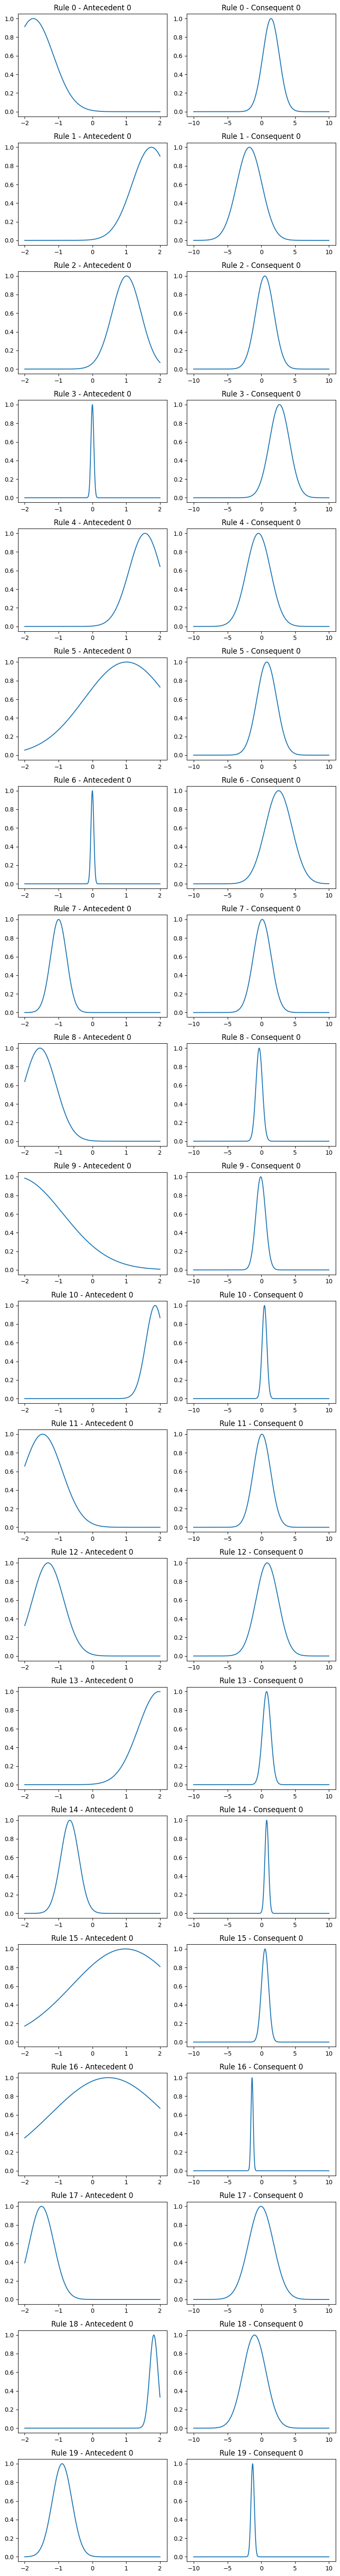

In [41]:
best_fuzzy_model.plot_network()